# Physical-boundary jet RG evolution

This notebook solves the modified time-like DGLAP evolution on a $1000\times1000$ lattice with VFNS, plots the evolved quark and gluon jet functions at six scales, and writes the plotted values to one `data/jet_rg_mu_*_GeV.csv` file per scale.

The boundary lies at
$$
\mu_*(b)=\frac{b_0}{b_*(b)},\qquad
b_*(b)=\frac{b}{\sqrt{1+b^2/b_0^2}}.
$$
At $(b_*,\mu_*)$, the perturbative logarithm $L_b=\ln(\mu_*^2b_*^2/b_0^2)$ vanishes. The NNLO boundary is therefore
$$
J_i(b,\mu_*)=\left[1+a_s(\mu_*)J_i^{(1)}(n_f)+a_s^2(\mu_*)J_i^{(2)}(n_f)\right]F_i^{\rm NP}(b),
\qquad a_s=\frac{\alpha_s}{4\pi},
$$
with $F_q^{\rm NP}=e^{-2.3b}$ and $F_g^{\rm NP}=e^{-3.8b}$. Both $\alpha_s(\mu_*)$ and every coefficient containing $n_f$ use $n_f=n_f(\mu_*)$ from VFNS; no fixed-$n_f=5$ constants are used. The zero-log perturbative constants are the EEC jet-function coefficients of [Dixon, Moult, and Zhu](https://arxiv.org/abs/1905.01310), also reproduced in the local Mathematica notebook `Collinear EEC/jet NNLO.nb`.

In [1]:
import os
import shutil
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

os.environ.setdefault("JULIA_NUM_THREADS", "auto")

if "Main" not in globals():
    from julia.api import Julia

    julia_env = os.environ.get("JULIA_EXE")
    if julia_env:
        julia_executable = Path(julia_env)
    else:
        julia_candidates = sorted(
            (Path(os.environ["LOCALAPPDATA"]) / "Programs").glob("Julia-*/bin/julia.exe")
        )
        if not julia_candidates:
            raise FileNotFoundError("Set JULIA_EXE to the installed julia executable.")
        julia_executable = julia_candidates[-1]

    jl = Julia(runtime=str(julia_executable), compiled_modules=False, threads="auto")
    from julia import Main

print(f"Julia {Main.eval('string(VERSION)')} with {Main.eval('Threads.nthreads()')} threads")

Julia 1.11.6 with 20 threads


In [2]:
cwd = Path.cwd()
rg_dir = cwd if (cwd / "generate_evolved_data.jl").exists() else cwd / "Numerical RG"
Main.include(str(rg_dir / "generate_evolved_data.jl"))

n_nodes = 1000
b_min = 0.001       # Required to include mu = 500 GeV in the solved plane.
b_max = 50.0        # Zero-closure endpoint.
mu_values = np.array([10.0, 20.0, 50.0, 100.0, 200.0, 500.0])
b_plot = np.geomspace(0.01, 5.0, 500)

Main.n_nodes = n_nodes
Main.b_min = b_min
Main.b_max = b_max

`build_evolved_interpolator` constructs the grid internally, so no prebuilt lattice is passed. All physical and numerical choices remain explicit below. `closure_check=:error` only rejects a boundary that is not negligible at `b_max`; it does not change the evolution.

In [3]:
start = time.perf_counter()
Main.eval(r"""
bstar_func(b) = b / sqrt(1.0 + b^2 / b0^2)
boundary_func = build_physical_boundary_func(
    order=2,
    nf_scheme=:VFNS,
    alpha_s_order=4,
)

solution = build_evolved_interpolator(
    n_nodes=n_nodes,
    b_min=b_min,
    b_max=b_max,
    bstar_func=bstar_func,
    boundary_func=boundary_func,
    order=2,
    nf_scheme=:VFNS,
    alpha_s_order=4,
    method=:rk2,
    closure_check=:error,
)
""")
solve_seconds = time.perf_counter() - start
print(f"{n_nodes} x {n_nodes} NNLO VFNS build: {solve_seconds:.2f} s")

1000 x 1000 NNLO VFNS build: 5.89 s


In [4]:
Main.b_plot_python = b_plot.tolist()
Main.mu_values_python = mu_values.tolist()
Main.eval(r"""
b_plot_vec = Float64.(b_plot_python)
mu_values_vec = Float64.(mu_values_python)
jq_plot = Matrix{Float64}(undef, length(mu_values_vec), length(b_plot_vec))
jg_plot = similar(jq_plot)

for i in eachindex(mu_values_vec), j in eachindex(b_plot_vec)
    value = solution(b_plot_vec[j], mu_values_vec[i])
    jq_plot[i, j] = value.jq
    jg_plot[i, j] = value.jg
end
""")

jq_plot = np.asarray(Main.jq_plot, dtype=float)
jg_plot = np.asarray(Main.jg_plot, dtype=float)
expected_shape = (mu_values.size, b_plot.size)
assert jq_plot.shape == expected_shape and jg_plot.shape == expected_shape
assert np.isfinite(jq_plot).all() and np.isfinite(jg_plot).all()

data_dir = rg_dir / "data"
data_dir.mkdir(exist_ok=True)
for mu, jq_values, jg_values in zip(mu_values, jq_plot, jg_plot):
    csv_path = data_dir / f"jet_rg_mu_{mu:g}_GeV.csv"
    np.savetxt(
        csv_path,
        np.column_stack((b_plot, jq_values, jg_values)),
        delimiter=",",
        header="b,Jq,Jg",
        comments="",
        fmt="%.16e",
    )
    print(f"Saved {csv_path}")

print(f"Jq range: [{jq_plot.min():.6g}, {jq_plot.max():.6g}]")
print(f"Jg range: [{jg_plot.min():.6g}, {jg_plot.max():.6g}]")

Saved c:\Users\congyue zhang\Desktop\EEC collinear bspace new\Numerical RG\data\jet_rg_mu_10_GeV.csv
Saved c:\Users\congyue zhang\Desktop\EEC collinear bspace new\Numerical RG\data\jet_rg_mu_20_GeV.csv
Saved c:\Users\congyue zhang\Desktop\EEC collinear bspace new\Numerical RG\data\jet_rg_mu_50_GeV.csv
Saved c:\Users\congyue zhang\Desktop\EEC collinear bspace new\Numerical RG\data\jet_rg_mu_100_GeV.csv
Saved c:\Users\congyue zhang\Desktop\EEC collinear bspace new\Numerical RG\data\jet_rg_mu_200_GeV.csv
Saved c:\Users\congyue zhang\Desktop\EEC collinear bspace new\Numerical RG\data\jet_rg_mu_500_GeV.csv
Jq range: [2.6508e-08, 1.03929]
Jg range: [6.64789e-10, 1.10056]


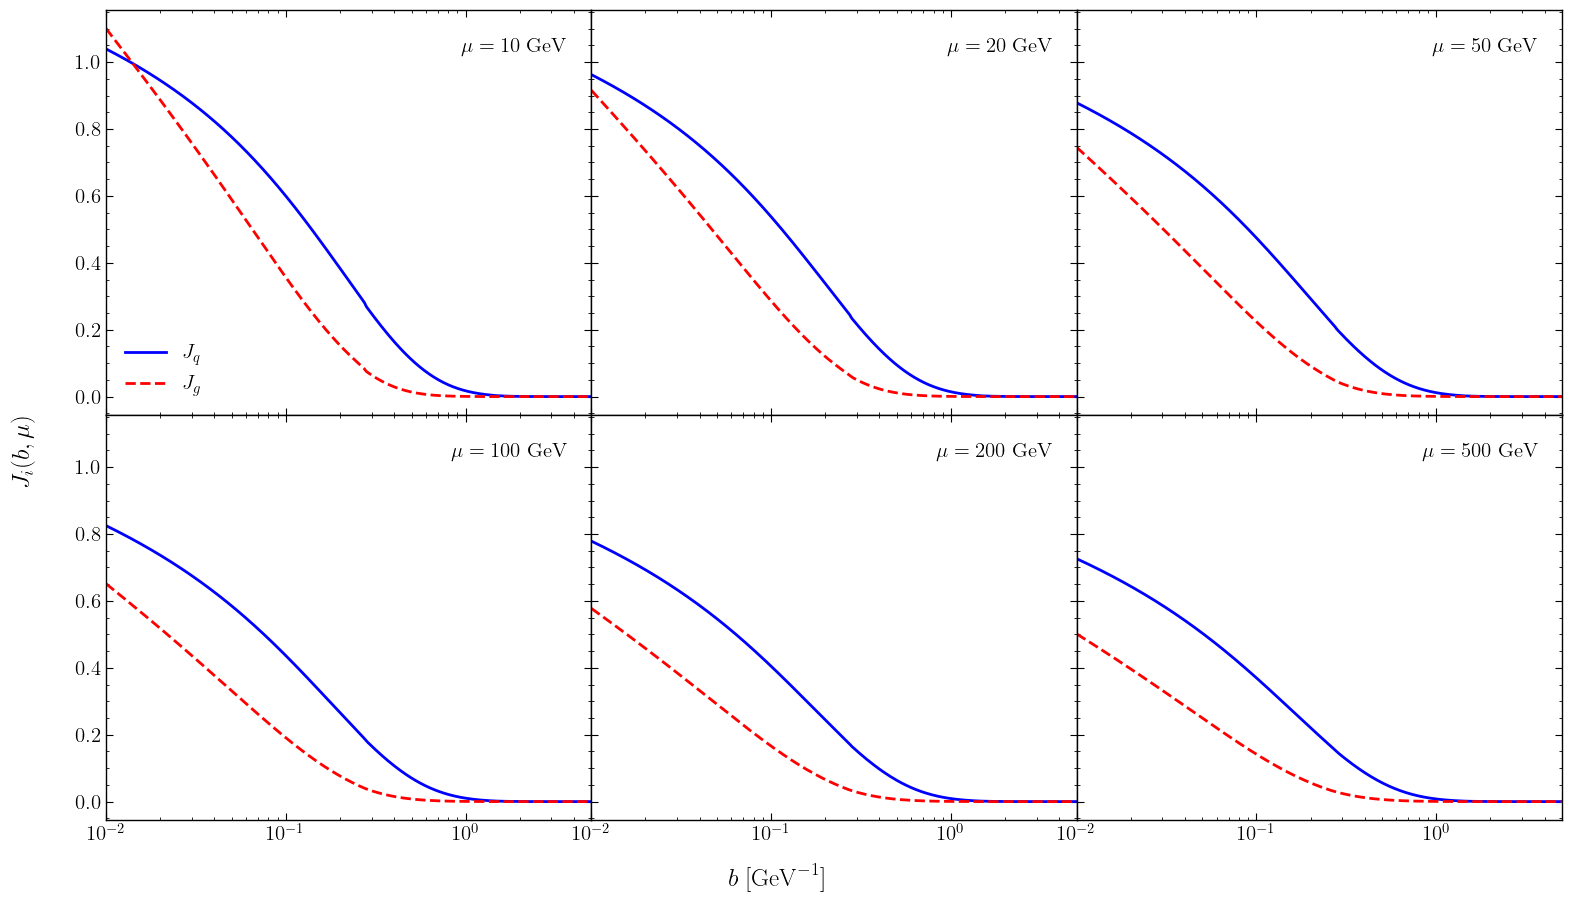

Saved c:\Users\congyue zhang\Desktop\EEC collinear bspace new\Numerical RG\jet_rg_vfns_2x3.png
Saved c:\Users\congyue zhang\Desktop\EEC collinear bspace new\Numerical RG\jet_rg_vfns_2x3.pdf


In [5]:
# Collinear-EEC paper plotting convention used by the existing plot notebooks.
plt.rcParams.update({
    "text.usetex": shutil.which("latex") is not None,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 15,
    "axes.linewidth": 1.0,
})

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)

for ax, mu, jq_values, jg_values in zip(axes.ravel(), mu_values, jq_plot, jg_plot):
    ax.plot(b_plot, jq_values, color="blue", linewidth=2.0, label=r"$J_q$")
    ax.plot(b_plot, jg_values, color="red", linewidth=2.0, linestyle="--", label=r"$J_g$")
    ax.text(
        0.95,
        0.93,
        rf"$\mu={mu:g}\ {{\rm GeV}}$",
        transform=ax.transAxes,
        ha="right",
        va="top",
    )
    ax.set_xscale("log")
    ax.set_xlim(0.01, 5.0)
    ax.minorticks_on()
    ax.tick_params(axis="both", direction="in", length=5, top=True, right=True)
    ax.tick_params(axis="both", which="minor", direction="in", length=2.5, top=True, right=True)

axes[0, 0].legend(frameon=False, loc="lower left")
fig.supxlabel(r"$b\ [{\rm GeV}^{-1}]$", fontsize=18)
fig.supylabel(r"$J_i(b,\mu)$", fontsize=18)
fig.subplots_adjust(left=0.08, right=0.99, bottom=0.09, top=0.99, wspace=0.0, hspace=0.0)

png_path = rg_dir / "jet_rg_vfns_2x3.png"
pdf_path = rg_dir / "jet_rg_vfns_2x3.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved {png_path}")
print(f"Saved {pdf_path}")